In [1]:
import os
import cv2
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt


### Đọc file ảnh và xuất ra 6 đặc trưng

In [8]:
fire = cv2.imread("fire/positive.png")
non_fire = cv2.imread("fire/negative.png")
test = cv2.imread("fire/test.png")

fire = cv2.resize(fire, (128, 128))
non_fire = cv2.resize(non_fire, (128, 128))

# KHÔNG resize test
def get_features(img):

    # OpenCV dùng thứ tự BGR
    B = img[:, :, 0]
    G = img[:, :, 1]
    R = img[:, :, 2]

    # 1. Tỷ lệ pixel màu lửa
    fire_pixel = (R > G) & (G > B) & (R > 150) & (G > 100)
    fire_ratio = np.mean(fire_pixel)

    # 2. Trung bình kênh đỏ
    mean_R = np.mean(R)

    # 3. Độ sáng
    gray = 0.299 * R + 0.587 * G + 0.114 * B
    mean_intensity = np.mean(gray)

    # 4. Độ lệch chuẩn độ sáng
    std_intensity = np.std(gray)

    # 5. Tỷ lệ pixel sáng
    bright_ratio = np.mean(gray > 200)

    # 6. Độ bão hòa màu
    hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
    S = hsv[:, :, 1]
    mean_S = np.mean(S)

    return [
        fire_ratio,
        mean_R,
        mean_intensity,
        std_intensity,
        bright_ratio,
        mean_S
    ]


# Lấy đặc trưng
fire_feature = get_features(fire)
non_fire_feature = get_features(non_fire)

print("Ảnh cháy:")
print(fire_feature)

print("\nẢnh không cháy:")
print(non_fire_feature)

Ảnh cháy:
[0.08648681640625, 113.02740478515625, 106.84253558349609, 45.50136700510577, 0.031494140625, 182.45989990234375]

Ảnh không cháy:
[0.03375244140625, 106.729248046875, 111.75093579101562, 46.07657797929056, 0.02618408203125, 198.64215087890625]


### Định nghĩa hàm khoảng cách Euclid và Mannhattan

In [9]:
def euclid(a, b):
    a = np.array(a)
    b = np.array(b)

    return np.sqrt(np.sum((a - b) ** 2))


def manhattan(a, b):
    a = np.array(a)
    b = np.array(b)

    return np.sum(np.abs(a - b))

### Sliding window và Template Matching

In [10]:
def detect_fire(test, method):

    h, w = test.shape[:2]

    result = test.copy()
    boxes = []

    # Sliding window 128x128, step = 32
    for y in range(0, h - 128 + 1, 32):
        for x in range(0, w - 128 + 1, 32):

            window = test[y:y+128, x:x+128]

            # 6 đặc trưng của cửa sổ
            feature = np.array(get_features(window))

            # Template Matching
            if method == "euclid":
                d_fire = euclid(feature, fire_feature)
                d_non_fire = euclid(feature, non_fire_feature)

            else:
                d_fire = manhattan(feature, fire_feature)
                d_non_fire = manhattan(feature, non_fire_feature)

            # Cửa sổ gần template cháy hơn
            if d_fire < d_non_fire:

                boxes.append((x, y, x+128, y+128))

                # box xanh
                cv2.rectangle(
                    result,
                    (x, y),
                    (x+128, y+128),
                    (255, 0, 0),
                    2
                )

    return result, boxes

### Chạy Euclid

In [11]:
result_euclid, boxes_euclid = detect_fire(
    test,
    "euclid"
)

print("Số cửa sổ dương tính Euclid:")
print(len(boxes_euclid))

Số cửa sổ dương tính Euclid:
780


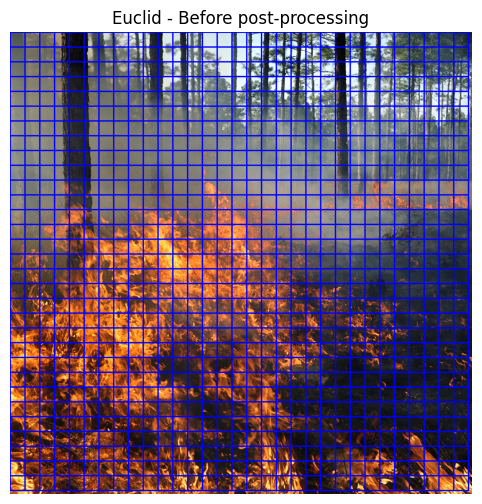

In [12]:
plt.figure(figsize=(10, 6))

plt.imshow(
    cv2.cvtColor(result_euclid, cv2.COLOR_BGR2RGB)
)

plt.title("Euclid - Before post-processing")
plt.axis("off")
plt.show()

### Chạy Manhattan

In [13]:
result_manhattan, boxes_manhattan = detect_fire(
    test,
    "manhattan"
)

print("Số cửa sổ dương tính Manhattan:")
print(len(boxes_manhattan))

Số cửa sổ dương tính Manhattan:
721


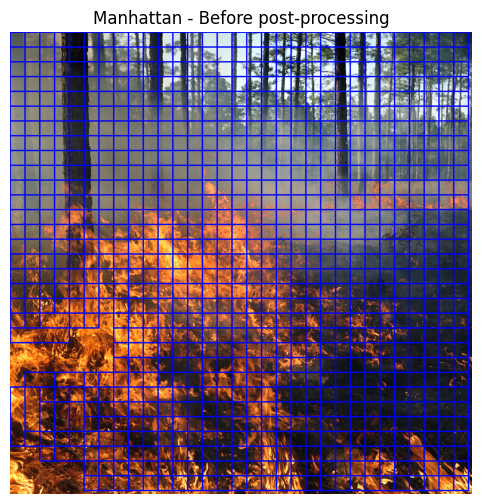

In [14]:
plt.figure(figsize=(10, 6))

plt.imshow(
    cv2.cvtColor(result_manhattan, cv2.COLOR_BGR2RGB)
)

plt.title("Manhattan - Before post-processing")
plt.axis("off")
plt.show()

### Hậu xử lí - Tránh trường hợp nhiều cửa số cho kết quả dương tính do bị chồng chập

In [15]:
def post_process(image, boxes):

    result = image.copy()

    if len(boxes) == 0:
        return result

    x1 = min(box[0] for box in boxes)
    y1 = min(box[1] for box in boxes)

    x2 = max(box[2] for box in boxes)
    y2 = max(box[3] for box in boxes)

    # box đỏ sau hậu xử lý
    cv2.rectangle(
        result,
        (x1, y1),
        (x2, y2),
        (0, 0, 255),
        3
    )

    return result

### Hậu xử lí Euclid

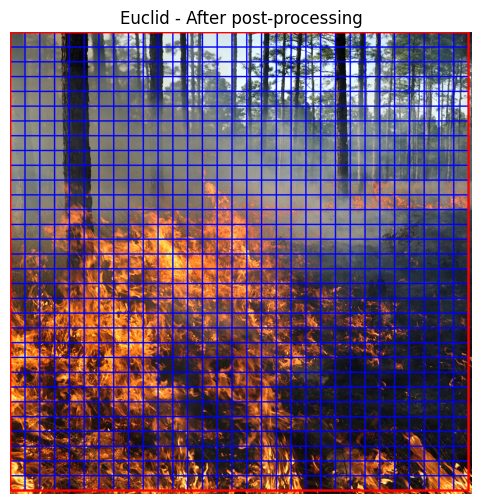

In [16]:
final_euclid = post_process(
    result_euclid,
    boxes_euclid
)

plt.figure(figsize=(10, 6))

plt.imshow(
    cv2.cvtColor(final_euclid, cv2.COLOR_BGR2RGB)
)

plt.title("Euclid - After post-processing")
plt.axis("off")
plt.show()

### Hậu xử lí Mannhatan

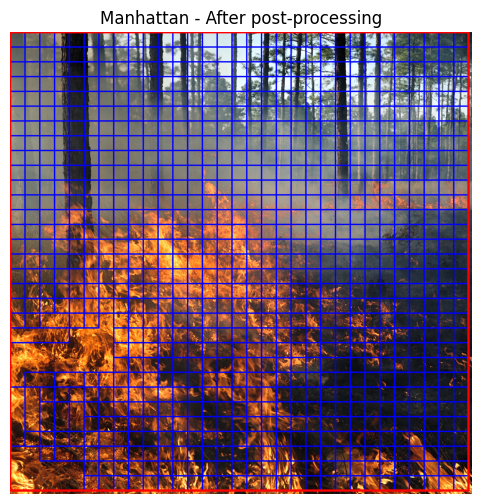

In [17]:
final_manhattan = post_process(
    result_manhattan,
    boxes_manhattan
)

plt.figure(figsize=(10, 6))

plt.imshow(
    cv2.cvtColor(final_manhattan, cv2.COLOR_BGR2RGB)
)

plt.title("Manhattan - After post-processing")
plt.axis("off")
plt.show()

In [18]:
print("Euclid:")
print("Số cửa sổ phát hiện cháy =", len(boxes_euclid))

print()

print("Manhattan:")
print("Số cửa sổ phát hiện cháy =", len(boxes_manhattan))

Euclid:
Số cửa sổ phát hiện cháy = 780

Manhattan:
Số cửa sổ phát hiện cháy = 721


### Đánh giá

In [19]:
print("ĐÁNH GIÁ")

print("Euclid:")
print("- Positive windows:", len(boxes_euclid))

print("Manhattan:")
print("- Positive windows:", len(boxes_manhattan))

ĐÁNH GIÁ
Euclid:
- Positive windows: 780
Manhattan:
- Positive windows: 721
